# major project

In [ ]:
import pandas as pd #linear algebra
import numpy as np #data processing, CSV file I/O
import re
import string
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=10,8
matplotlib.get_backend()
df = pd.read_csv('Information.csv',encoding='latin1')

# reading the data

In [ ]:
df.head(2)

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,profileimage,retweet_count,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0,yes,1.0,12/5/13 1:48,...,https://pbs.twimg.com/profile_images/414342229...,0,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0,yes,1.0,10/1/12 13:51,...,https://pbs.twimg.com/profile_images/539604221...,0,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada)


In [ ]:
df.columns

Index(['_unit_id', '_golden', '_unit_state', '_trusted_judgments',
       '_last_judgment_at', 'gender', 'gender:confidence', 'profile_yn',
       'profile_yn:confidence', 'created', 'description', 'fav_number',
       'gender_gold', 'link_color', 'name', 'profile_yn_gold', 'profileimage',
       'retweet_count', 'sidebar_color', 'text', 'tweet_coord', 'tweet_count',
       'tweet_created', 'tweet_id', 'tweet_location', 'user_timezone'],
      dtype='object')

In [ ]:
#taking only required number of columns for data analysis
data = pd.read_csv("Information.csv",usecols= [0,5,19,17,21,10,11],encoding='latin1')

In [ ]:
data.head(2)

,_unit_id,gender,description,fav_number,retweet_count,text,tweet_count
0,815719226,male,i sing my own rhythm.,0,0,Robbie E Responds To Critics After Win Against...,110964
1,815719227,male,I'm the author of novels filled with family dr...,68,0,ÛÏIt felt like they were my friends and I was...,7471


# cleaning the data

In [ ]:
#removing genders other than male and female

In [ ]:
df = df[(df['gender'] == 'male') | (df['gender'] == 'female')]

In [ ]:

# LABEL ENCODING _golden, _unit_state
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['_golden2'] = le.fit_transform(df['_golden'])
df['_unit_state2'] = le.fit_transform(df['_unit_state'])
df['gender2'] = le.fit_transform(df['gender'])
df['_unit_state2'] = le.fit_transform(df['_unit_state'])

In [ ]:
#removing unwanted column from the dataset
df.drop(labels=['_unit_id'],axis=1,inplace=True)

# questions asked on the dataset 

# Question1 What are the most common emotions/words used by Males and Females?


In [ ]:
#cleaning the data 
#splitting the sentences to inidividual words
def cleaning(s):
    s = str(s)
    s = s.lower()
    s = re.sub('\s\W',' ',s)
    s = re.sub('\W,\s',' ',s)
    s = re.sub(r'[^\w]', ' ', s)
    s = re.sub("\d+", "", s)
    s = re.sub('\s+',' ',s)
    s = re.sub('[!@#$_]', '', s)
    s = s.replace("co","")
    s = s.replace("https","")
    s = s.replace(",","")
    s = s.replace("[\w*"," ")
    return s

data['Tweets'] = [cleaning(s) for s in data['text']]
data['Description'] = [cleaning(s) for s in data['description']]


In [ ]:
data.head(2)

,_unit_id,gender,description,fav_number,retweet_count,text,tweet_count,Tweets,Description
0,815719226,male,i sing my own rhythm.,0,0,Robbie E Responds To Critics After Win Against...,110964,robbie e responds to critics after win against...,i sing my own rhythm
1,815719227,male,I'm the author of novels filled with family dr...,68,0,ÛÏIt felt like they were my friends and I was...,7471,ûïit felt like they were my friends and i was...,i m the author of novels filled with family dr...


In [ ]:
data = data[(data['gender'] == 'male') | (data['gender'] == 'female')]


In [ ]:
data.gender.value_counts()

female    6700
male      6194
Name: gender, dtype: int64

In [ ]:
Male = data[data['gender'] == 'male']
Female = data[data['gender'] == 'female']
Male_Words = pd.Series(' '.join(Male['Tweets'].astype(str)).lower().split(" ")).value_counts()[:20]
Female_Words = pd.Series(' '.join(Female['Tweets'].astype(str)).lower().split(" ")).value_counts()[:20]

In [ ]:
Female_Words

        8441
and     4844
the     4775
i       3554
t       2883
to      2290
you     1813
a       1582
of      1293
ù       1285
it      1258
my      1247
in      1228
for     1139
me      1088
is      1078
s        910
that     785
on       785
so       663
dtype: int64

<AxesSubplot:>

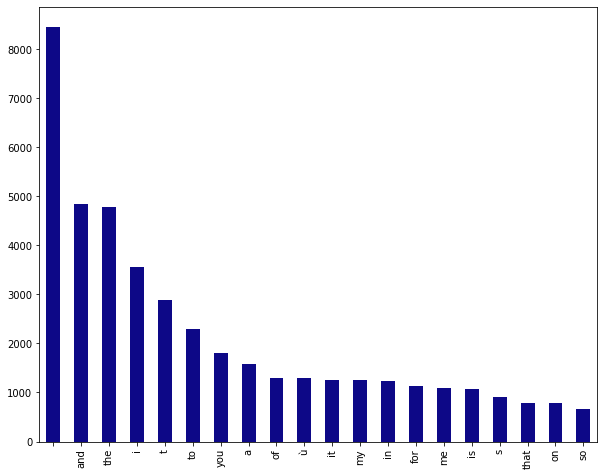

In [ ]:
#As you can see 'and' word is most commonly used by female if you exclude ' 'character
Female_Words.plot(kind='bar',stacked=True, colormap='plasma')

In [ ]:
Male_Words

        8701
the     5062
and     4061
t       2684
i       2415
to      1990
a       1777
you     1563
of      1433
in      1194
it      1128
for     1041
is      1031
s        873
on       836
that     739
me       676
my       651
with     534
be       518
dtype: int64

<AxesSubplot:>

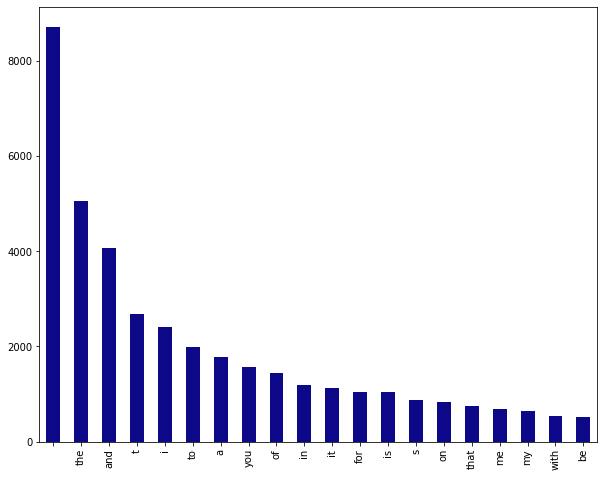

In [ ]:

Male_Words.plot(kind='bar',stacked=True, colormap='plasma')

#A bar graph is plotted acoording to the usage of words
#As you can see 'the' word is most commonly used word by males if you exclude ' 'character

# Question 2 What is the highest tweet_count got by a male and female?

In [ ]:
Male = df[df['gender'] == 'male']
Female = df[df['gender'] == 'female']
df[Male.notnull()][['gender:confidence','gender','tweet_count']].sort_values('gender',ascending=False).head(1)
#for male

,gender:confidence,gender,tweet_count
0,1.0,male,110964.0


In [ ]:
df[Female.notnull()][['gender:confidence','gender','tweet_count']].sort_values('gender',ascending=False).head(1)
#for female

,gender:confidence,gender,tweet_count
4,1.0,female,31462.0


# Calculating gender count in the dataset

In [ ]:

df['gender'].value_counts()

female    6700
male      6194
Name: gender, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12894 entries, 0 to 20049
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   _golden                12894 non-null  bool   
 1   _unit_state            12894 non-null  object 
 2   _trusted_judgments     12894 non-null  int64  
 3   _last_judgment_at      12858 non-null  object 
 4   gender                 12894 non-null  object 
 5   gender:confidence      12894 non-null  float64
 6   profile_yn             12894 non-null  object 
 7   profile_yn:confidence  12894 non-null  float64
 8   created                12894 non-null  object 
 9   description            11194 non-null  object 
 10  fav_number             12894 non-null  int64  
 11  gender_gold            36 non-null     object 
 12  link_color             12894 non-null  object 
 13  name                   12894 non-null  object 
 14  profile_yn_gold        36 non-null     object 
 15  pr

# To check the correlation between columns

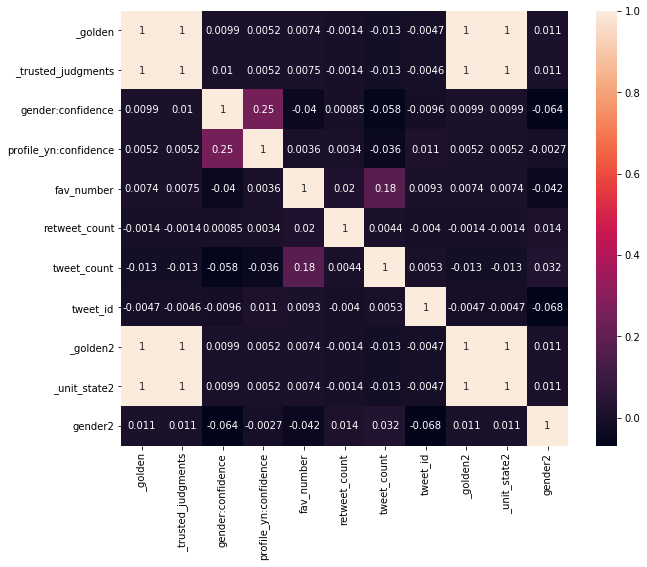

In [ ]:
import seaborn as sb
sb.heatmap(df.corr(), annot=True)

In [ ]:
df.describe()

,_trusted_judgments,gender:confidence,profile_yn:confidence,fav_number,retweet_count,tweet_count,tweet_id,_golden2,_unit_state2,gender2
count,12894.000000,12894.000000,12894.000000,12894.000000,12894.000000,1.289400e+04,1.289400e+04,12894.000000,12894.000000,12894.000000
mean,3.690631,0.916154,0.994840,5475.316194,0.067008,2.945312e+04,6.587354e+17,0.002792,0.002792,0.480378
std,13.067179,0.165393,0.041333,13118.359541,1.524385,7.072127e+04,4.980197e+12,0.052768,0.052768,0.499634
min,3.000000,0.320600,0.630800,0.000000,0.000000,1.000000e+00,6.587300e+17,0.000000,0.000000,0.000000
25%,3.000000,1.000000,1.000000,137.000000,0.000000,2.273750e+03,6.587300e+17,0.000000,0.000000,0.000000
50%,3.000000,1.000000,1.000000,1126.000000,0.000000,9.306000e+03,6.587400e+17,0.000000,0.000000,0.000000
75%,3.000000,1.000000,1.000000,4956.500000,0.000000,3.023525e+04,6.587400e+17,0.000000,0.000000,1.000000
max,274.000000,1.000000,1.000000,341621.000000,153.000000,2.680199e+06,6.587400e+17,1.000000,1.000000,1.000000


In [ ]:
df.columns


Index(['_golden', '_unit_state', '_trusted_judgments', '_last_judgment_at',
       'gender', 'gender:confidence', 'profile_yn', 'profile_yn:confidence',
       'created', 'description', 'fav_number', 'gender_gold', 'link_color',
       'name', 'profile_yn_gold', 'profileimage', 'retweet_count',
       'sidebar_color', 'text', 'tweet_coord', 'tweet_count', 'tweet_created',
       'tweet_id', 'tweet_location', 'user_timezone', '_golden2',
       '_unit_state2', 'gender2'],
      dtype='object')

In [ ]:
df.describe().columns
df.dtypes

_golden                     bool
_unit_state               object
_trusted_judgments         int64
_last_judgment_at         object
gender                    object
gender:confidence        float64
profile_yn                object
profile_yn:confidence    float64
created                   object
description               object
fav_number                 int64
gender_gold               object
link_color                object
name                      object
profile_yn_gold           object
profileimage              object
retweet_count              int64
sidebar_color             object
text                      object
tweet_coord               object
tweet_count                int64
tweet_created             object
tweet_id                 float64
tweet_location            object
user_timezone             object
_golden2                   int64
_unit_state2               int32
gender2                    int32
dtype: object

# Ensemble Machine learning Modelling (3 Classification Algorithms)

#Dependant variable is 'gender'

#Independant variables are 'tweet_id','retweet_count', 'tweet_count'

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df[['tweet_id','retweet_count', 'tweet_count']].values
Y = df[['gender']].values

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y)

In [ ]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((9670, 3), (3224, 3), (9670, 1), (3224, 1))

# 1. K Nearest Neighbor(KNN) 

The k-nearest-neighbors algorithm is a classification algorithm, and it is supervised: it takes a bunch of labelled points and uses them to learn how to label other points. To label a new point, it looks at the labelled points closest to that new point (those are its nearest neighbors), and has those neighbors vote, so whichever label the most of the neighbors have is the label for the new point (the “k” is the number of neighbors it checks).

In [ ]:
#importing the algorithm
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#here we compute KNN algorithm for value 1
knn = KNeighborsClassifier(n_neighbors=1)

In [ ]:
knn

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='uniform')

In [ ]:
knn.fit(X_train, Y_train.ravel())

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='uniform')

In [ ]:
#taking the predicting value with X_test
Y_pred = knn.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
#to calculate the accuracy of the algorithm

# Accuracy

In [ ]:
accuracy_score(Y_test, Y_pred)*100
#here we can see we got the accuracy of 51%

51.6439205955335

# 2.Logistic Regression (Predictive Learning Model) :

Logistic regression is a technique in statistical analysis that attempts to predict a data value based on prior observation. The outcome is measured with a dichotomous variable (in which there are only two possible outcomes). The goal of logistic regression is to find the best fitting model to describe the relationship between the dichotomous characteristic of interest (dependent variable = response or outcome variable) and a set of independent (predictor or explanatory) variables.

In [ ]:
from sklearn.linear_model import LogisticRegression
#importing the algorithm

In [ ]:
LogReg = LogisticRegression()

In [ ]:
LogReg.fit(X_train, Y_train.ravel())

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

# Accuracy

In [ ]:
LogReg.score(X_test,Y_test)*100
#Here we got the accuracy of 51%

51.302729528535984

# 3.Decision Trees

A decision tree is a graphical representation of specific decision situations that are used when complex branching occurs in a structured decision process. It breaks down a data set into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed. The final result is a tree with decision nodes and leaf nodes. A decision node has two or more branches and a leaf node represents a classification or decision. The topmost decision node in a tree which corresponds to the best predictor called root node. Decision trees can handle both categorical and numerical data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier(criterion='gini')
#Gini Index — The Gini coefficient measures the inequality among values of a distributed groups. 
#It takes values from 0–1. A Gini coefficient of zero expresses perfect equality where all values are the same . 
#A Gini coefficient of one \ expresses maximal inequality among values.

In [ ]:
dt.fit(X_train,Y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [ ]:
actual=Y
predict=dt.predict(X)

In [ ]:
from sklearn import metrics

# Accuracy

In [ ]:
print(metrics.accuracy_score(actual,predict)*100)
#here we can see we got the accuracy of 84%

84.3027764851869


# Conclusion

# After applying Train/Test split method and comparing the three classification models i.e Logistic algorithm ,KNN(n=1) and Decision Trees , we conclude that Decision Trees algorithm suits best with 84% accuracy and the Logistic with next highest accuracy of 51.6% and last KNN  with 51.3% for k=1

However, since we only used train split method for accuracy calculation, we got decision trees with highest accuracy 

However, if we use other methods like cross-validation or training model with entire data set we get different accuracies

and different algorithm model with highest accuracy 